# 7. Sampling and Reconstruction of Signals: Analysis of Aliasing Effects and Proper Signal Reconstruction

## Example 1: Demonstration of Aliasing

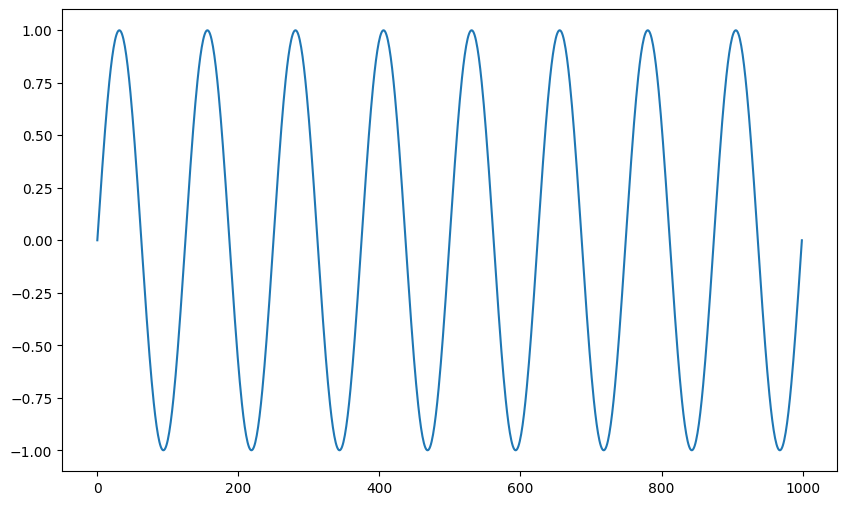

In [19]:
import numpy as np
import matplotlib.pyplot as plt

f_sample_low = 8  # Low sampling frequency (Hz)

fs = 1000 
t = np.linspace(0, 1, fs)

signal = np.sin(2 * np.pi * f_sample_low * t)  # Original signal

plt.figure(figsize=(10, 6))
plt.plot(signal, label='Low Sampling')
plt.show()

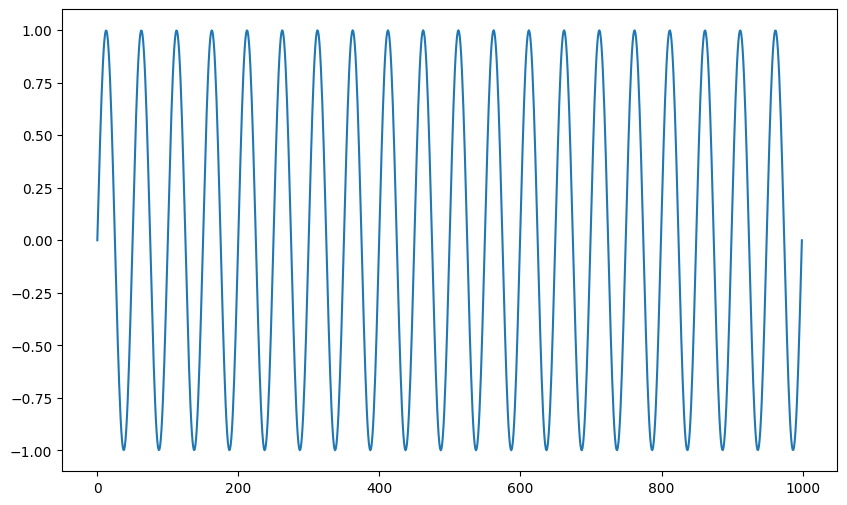

In [20]:
import numpy as np
import matplotlib.pyplot as plt

f_sample_high = 20  # High sampling frequency (Hz)

fs = 1000 
t = np.linspace(0, 1, fs)

signal = np.sin(2 * np.pi * f_sample_high * t)  # Original signal

plt.figure(figsize=(10, 6))
plt.plot(signal, label='f_sample_high Sampling')
plt.show()

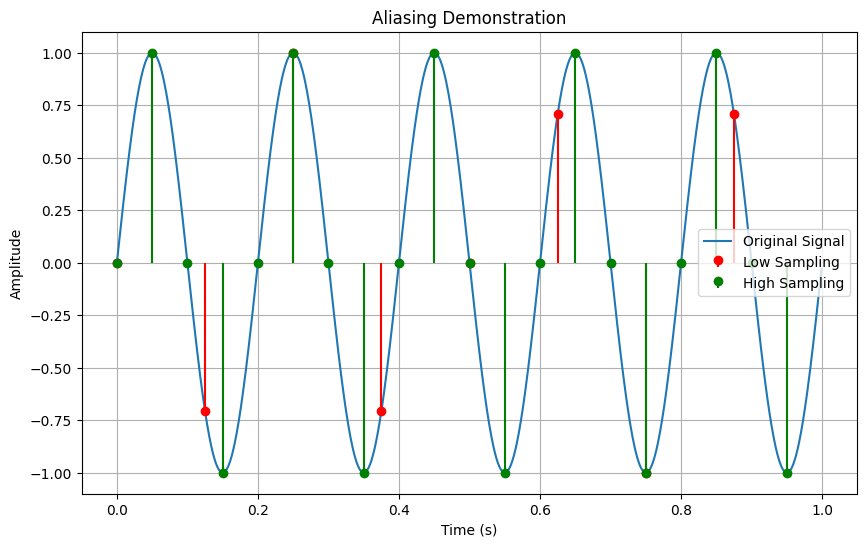

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Original signal parameters
f_signal = 5  # Frequency of the signal (Hz)
t = np.linspace(0, 1, 1000, endpoint=False)  # Time vector
signal = np.sin(2 * np.pi * f_signal * t)  # Original signal

# Sampling parameters
f_sample_low = 8  # Low sampling frequency (Hz)
f_sample_high = 20  # High sampling frequency (Hz)

# Sampling the signal
t_low = np.arange(0, 1, 1 / f_sample_low)
t_high = np.arange(0, 1, 1 / f_sample_high)
samples_low = np.sin(2 * np.pi * f_signal * t_low)
samples_high = np.sin(2 * np.pi * f_signal * t_high)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, signal, label='Original Signal')
plt.stem(t_low, samples_low, linefmt='r-', markerfmt='ro', basefmt=" ", label='Low Sampling')
plt.stem(t_high, samples_high, linefmt='g-', markerfmt='go', basefmt=" ", label='High Sampling')
plt.title('Aliasing Demonstration')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

## Example 2: Signal Reconstruction

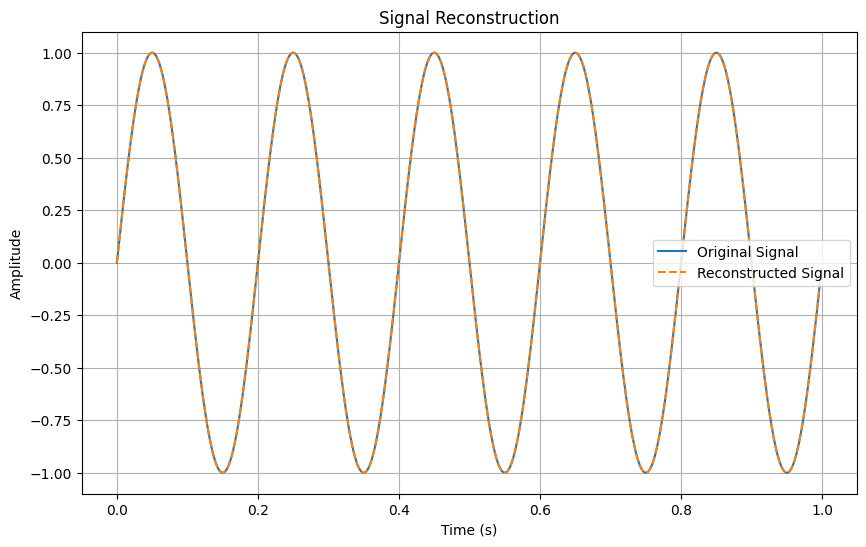

In [23]:
from scipy.signal import resample

# Reconstructing the signal using high sampling rate
num_samples = 1000
reconstructed_signal = resample(samples_high, num_samples)

# Plotting the reconstruction
plt.figure(figsize=(10, 6))
plt.plot(t, signal, label='Original Signal')
plt.plot(t, reconstructed_signal, label='Reconstructed Signal', linestyle='--')
plt.title('Signal Reconstruction')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

# Constructing Different Types of Waves

## Sine Wave

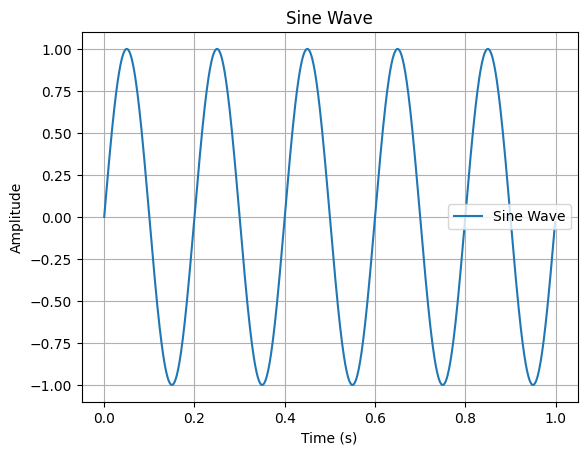

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
f = 5  # Frequency (Hz)
t = np.linspace(0, 1, 1000, endpoint=False)  # Time vector
sine_wave = np.sin(2 * np.pi * f * t)

# Plotting
plt.plot(t, sine_wave, label="Sine Wave")
plt.title("Sine Wave")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

## Cosine Wave

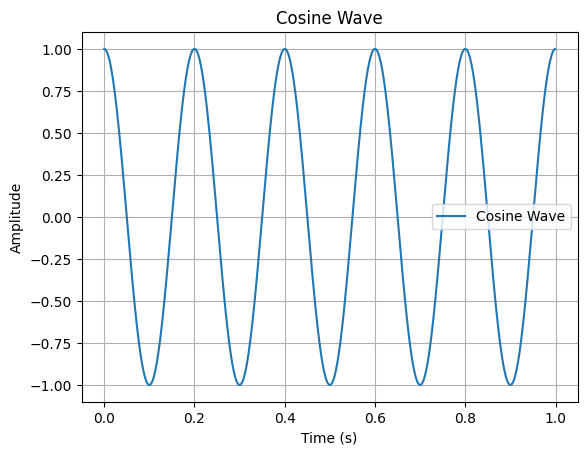

In [4]:
# Cosine wave
cosine_wave = np.cos(2 * np.pi * f * t)

# Plotting
plt.plot(t, cosine_wave, label="Cosine Wave")
plt.title("Cosine Wave")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

## Square Wave

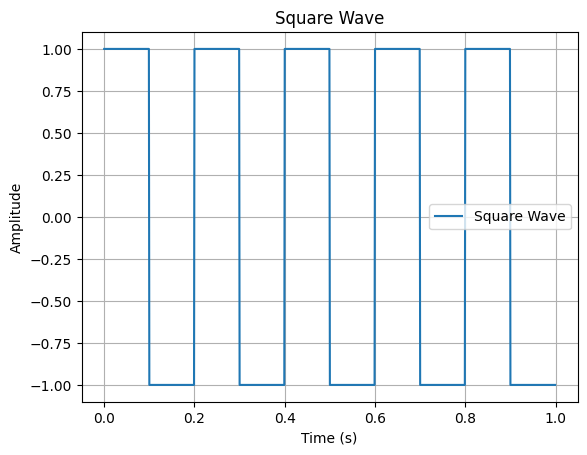

In [5]:
from scipy.signal import square

# Square wave
square_wave = square(2 * np.pi * f * t)

# Plotting
plt.plot(t, square_wave, label="Square Wave")
plt.title("Square Wave")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

## Triangular Wave

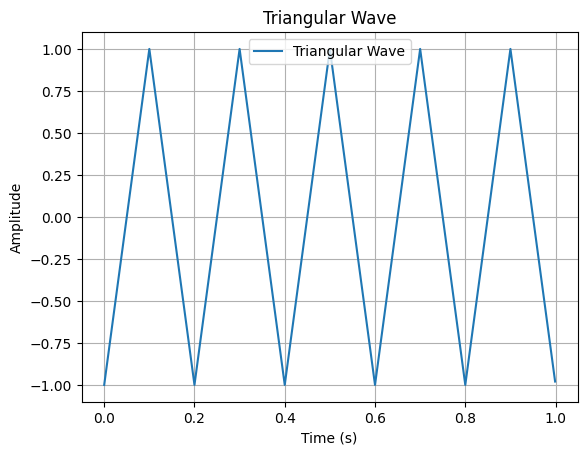

In [6]:
from scipy.signal import sawtooth

# Triangular wave (modification of sawtooth wave)
triangular_wave = sawtooth(2 * np.pi * f * t, width=0.5)

# Plotting
plt.plot(t, triangular_wave, label="Triangular Wave")
plt.title("Triangular Wave")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

## Sawtooth Wave

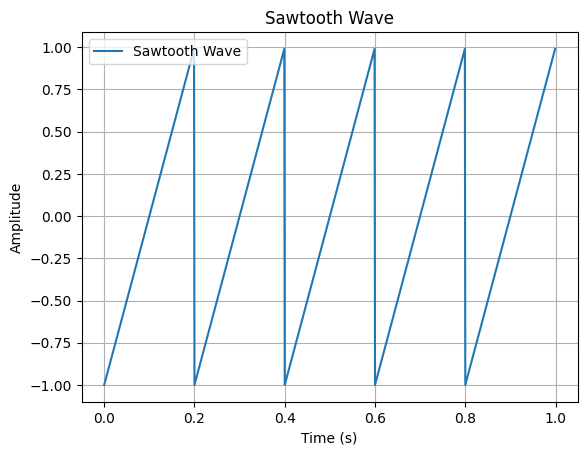

In [7]:
# Sawtooth wave
sawtooth_wave = sawtooth(2 * np.pi * f * t)

# Plotting
plt.plot(t, sawtooth_wave, label="Sawtooth Wave")
plt.title("Sawtooth Wave")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

## Mixed signal: sum of sine and cosine waves

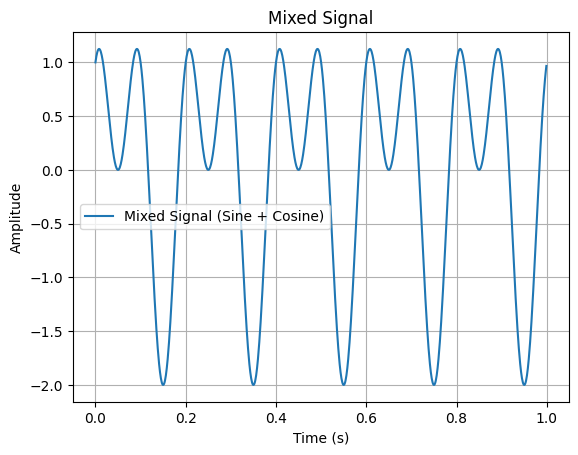

In [8]:
f1 = 5  # Frequency of sine wave
f2 = 10  # Frequency of cosine wave
mixed_signal = np.sin(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)

# Plotting
plt.plot(t, mixed_signal, label="Mixed Signal (Sine + Cosine)")
plt.title("Mixed Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

# Coding and Decoding Digital Signals

## Delta Encoding and Decoding

Delta encoding represents differences between consecutive signal samples.

In [9]:
import numpy as np

# Delta Encoding
# np.diff()
# dff(x)=x[i+1]−x[i]
# np x = [1, 3, 6, 10] wynik x = [2, 3, 4]
# bo 3 − 1 = 2, 6 − 3 = 3, 10 − 6 = 4
def delta_encode(signal):
    return np.diff(np.insert(signal, 0, signal[0]))

# Delta Decoding
# np.cumsum
# liczy sumę skumulowaną (narastającą) elementów tablicy.
# x = [1, 2, 3, 4] wynik x = [1, 3, 6, 10]
# bo 1, 1 + 2 = 3, 1 + 2 + 3 = 6, 1 + 2 + 3 + 4 = 10
def delta_decode(encoded_signal):
    return np.cumsum(encoded_signal)

# Example
original_signal = [1, 2, 2, 3, 5, 8]
encoded_signal = delta_encode(original_signal)
decoded_signal = delta_decode(encoded_signal)

print("Original Signal:", original_signal)
print("Encoded Signal:", encoded_signal)
print("Decoded Signal:", decoded_signal)

Original Signal: [1, 2, 2, 3, 5, 8]
Encoded Signal: [0 1 0 1 2 3]
Decoded Signal: [0 1 1 2 4 7]


## Quantization of Signal Samples
Quantization reduces the precision of signal samples to save storage or bandwidth.

In [10]:
# Kwantyzacja
# Służy do redukcji precyzji próbek sygnału w celu zmniejszenia ilości danych i oszczędzenia miejsca (kompresji).

def quantize(signal, levels):
    min_val, max_val = min(signal), max(signal)
    step_size = (max_val - min_val) / levels
    quantized_signal = np.round((signal - min_val) / step_size) * step_size + min_val
    return quantized_signal

# Example
original_signal = np.array([1.1, 2.3, 2.9, 3.7, 5.1])
quantized_signal = quantize(original_signal, levels=3)

print("Original Signal:", original_signal)
print("Quantized Signal:", quantized_signal)

Original Signal: [1.1 2.3 2.9 3.7 5.1]
Quantized Signal: [1.1        2.43333333 2.43333333 3.76666667 5.1       ]


## Reconstructing Signals After Compression

In [11]:
#This example demonstrates signal reconstruction after compression using a simple DCT.
from scipy.fftpack import dct, idct

# Apply Discrete Cosine Transform (DCT)
def apply_dct(signal):
    return dct(signal, norm='ortho')

# Reconstruct signal using inverse DCT
def reconstruct_signal(dct_signal, threshold):
    dct_signal[np.abs(dct_signal) < threshold] = 0
    return idct(dct_signal, norm='ortho')

# Example
original_signal = np.array([1, 2, 3, 4, 5, 6, 7, 8])
dct_signal = apply_dct(original_signal)
reconstructed_signal = reconstruct_signal(dct_signal, threshold=5)

print("Original Signal:", original_signal)
print("Compressed Signal:", dct_signal)
print("Reconstructed Signal:", np.round(reconstructed_signal, 2))

Original Signal: [1 2 3 4 5 6 7 8]
Compressed Signal: [12.72792206 -6.44232302  0.          0.          0.          0.
  0.          0.        ]
Reconstructed Signal: [1.34 1.82 2.71 3.87 5.13 6.29 7.18 7.66]


## Trade-off Analysis Between Compression Ratio and Signal Distortion

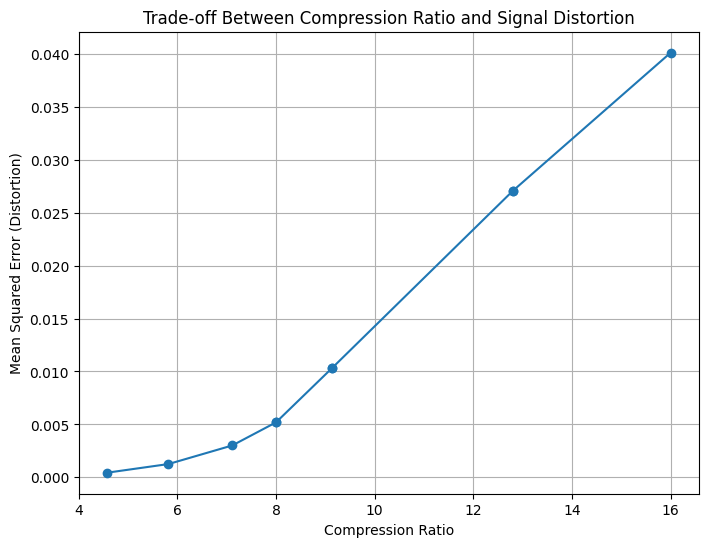

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

# Original Signal
N = 64  # Number of samples
t = np.linspace(0, 1, N)
signal = np.sin(2 * np.pi * 5 * t)  # Example sine wave

# Function for compression, reconstruction, and analysis
def analyze_tradeoff(signal, thresholds):
    original_size = len(signal)
    results = {"thresholds": [], "compression_ratios": [], "distortions": []}

    for threshold in thresholds:
        # Apply DCT
        dct_coeffs = dct(signal, norm='ortho')

        # Apply Thresholding (Compression)
        compressed_coeffs = np.where(abs(dct_coeffs) > threshold, dct_coeffs, 0)

        # Calculate Compression Ratio
        compressed_size = np.count_nonzero(compressed_coeffs)
        compression_ratio = original_size / compressed_size

        # Reconstruct Signal
        reconstructed_signal = idct(compressed_coeffs, norm='ortho')

        # Calculate Distortion (MSE)
        mse = np.mean((signal - reconstructed_signal) ** 2)

        # Store Results
        results["thresholds"].append(threshold)
        results["compression_ratios"].append(compression_ratio)
        results["distortions"].append(mse)

    return results

# Perform Analysis for a Range of Thresholds
thresholds = np.linspace(0.1, 1.0, 10)  # Threshold values
results = analyze_tradeoff(signal, thresholds)

# Plot Compression Ratio vs. Distortion
plt.figure(figsize=(8, 6))
plt.plot(results["compression_ratios"], results["distortions"], marker='o')
plt.title("Trade-off Between Compression Ratio and Signal Distortion")
plt.xlabel("Compression Ratio")
plt.ylabel("Mean Squared Error (Distortion)")
plt.grid()
plt.show()
